In [1]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(asctime)s %(levelname)s %(name)s: %(message)s')

import os
import yaml
from collections import defaultdict
from copy import deepcopy
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tqdm import tqdm
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy import table, time

import galsim
from romanisim import image, parameters, wcs
import romanisim.bandpass

import mejiro
from mejiro.utils import util as mejiro_util

# read config
config_file = os.path.join(os.path.dirname(mejiro.__file__), 'data', 'mejiro_config', 'roman_data_challenge_rung_1.yaml')
with open(config_file, 'r') as f:
    config = yaml.load(f, Loader=yaml.SafeLoader)
if config['dev']:
    config['pipeline_label'] += '_dev'

print(f"Pipeline label: {config['pipeline_label']}")
print(f"Data dir:       {config['data_dir']}")

Pipeline label: roman_data_challenge_rung_1
Data dir:       /nfsdata1/bwedig/mejiro


## Step 0: Discover SCA Directories

Scan the stage-04 output directory to find all `SyntheticImage_*.pkl` files, grouped by SCA and band.

In [2]:
data_dir = os.path.join(config['data_dir'], config['pipeline_label'], '04')
sca_dirs = sorted(glob(os.path.join(data_dir, 'sca*')))
print(f'Found {len(sca_dirs)} SCA directories in {data_dir}\n')

pickles_by_sca_band = {}
for sca_dir in sca_dirs:
    sca_num = int(os.path.basename(sca_dir)[3:])
    sca_pickles = sorted(glob(os.path.join(sca_dir, 'SyntheticImage_*.pkl')))
    by_band = defaultdict(list)
    for p in sca_pickles:
        band = os.path.basename(p).replace('.pkl', '').split('_')[-1]
        by_band[band].append(p)
    pickles_by_sca_band[sca_num] = dict(by_band)

# summary table
all_bands = sorted({b for bd in pickles_by_sca_band.values() for b in bd})
header = f"{'SCA':<5}" + "".join(f"{b:>8}" for b in all_bands)
print(header)
print('-' * len(header))
for sca_num in sorted(pickles_by_sca_band):
    row = f"  {sca_num:02d} " + "".join(f"{len(pickles_by_sca_band[sca_num].get(b, [])):>8}" for b in all_bands)
    print(row)

Found 18 SCA directories in /nfsdata1/bwedig/mejiro/roman_data_challenge_rung_1/04

SCA      F106    F129    F158
-----------------------------
  01     5734    5734    5734
  02     5719    5719    5719
  03     5875    5875    5875
  04     5823    5823    5823
  05     5962    5962    5962
  06     6014    6014    6014
  07     5929    5929    5929
  08     5953    5953    5953
  09     6073    6073    6073
  10     5794    5794    5794
  11     5921    5921    5921
  12     6235    6235    6235
  13     5693    5693    5693
  14     5838    5838    5838
  15     5680    5680    5680
  16     5821    5821    5821
  17     6146    6146    6146
  18     6489    6489    6489


## Development Parameters

Select a single SCA and band to process. Adjust `DEV_SCA`, `DEV_BAND`, and `DEV_N` to explore different data. `DEV_N` controls how many images are tiled into the full detector array — a full batch is 3136 (a 56×56 grid of 73×73 tiles).

In [3]:
# === development parameters ===
DEV_SCA  = 1        # SCA number (1–18)
DEV_BAND = 'F106'   # one of: 'F106', 'F129', 'F158'
DEV_N    = 100      # images to tile (≤ N_TILES = 3136); set to None to use the full batch

# tiling constants (must match the production script)
TILE_SIZE = 73
GRID_SIDE = 56
N_TILES   = GRID_SIDE * GRID_SIDE  # 3136

# exposure parameters from config
ma_table_number = config['exposure']['ma_table_number']
date = config['exposure']['date']
if not isinstance(date, str):
    date = date.isoformat()
coord = SkyCoord(
    ra=config['exposure']['coordinates']['ra'] * u.deg,
    dec=config['exposure']['coordinates']['dec'] * u.deg,
)

read_pattern = parameters.read_pattern[ma_table_number]
exptime = parameters.read_time * read_pattern[-1][-1]

# band-specific AB flux for unit conversion
abflux = romanisim.bandpass.get_abflux(DEV_BAND, DEV_SCA)

# deterministic RNGs (same seeding logic as production script)
seed       = config['seed']
band_idx   = ['F106', 'F129', 'F158'].index(DEV_BAND)
batch_seed = seed + DEV_SCA * 10000 + band_idx * 1000
rng        = galsim.UniformDeviate(batch_seed)
rng_np     = np.random.default_rng(batch_seed)

# select pickles for this SCA/band
all_pickles = pickles_by_sca_band[DEV_SCA][DEV_BAND]
dev_pickles = all_pickles[:DEV_N] if DEV_N is not None else all_pickles[:N_TILES]
n_images    = len(dev_pickles)

print(f'SCA:          {DEV_SCA:02d}')
print(f'Band:         {DEV_BAND}')
print(f'MA table:     {ma_table_number}  ->  {exptime:.1f} s exposure')
print(f'AB flux:      {abflux:.4e} e/s per maggy')
print(f'Observation:  {date}  |  RA={coord.ra.deg:.1f} deg, Dec={coord.dec.deg:.1f} deg')
print(f'Tile size:    {TILE_SIZE}x{TILE_SIZE} px')
print(f'Full grid:    {GRID_SIDE}x{GRID_SIDE} = {N_TILES} tiles')
print(f'Dev images:   {n_images}')

SCA:          01
Band:         F106
MA table:     17  ->  610.4 s exposure
AB flux:      3.3582e+10 e/s per maggy
Observation:  2027-01-01T00:00:00  |  RA=270.0 deg, Dec=66.0 deg
Tile size:    73x73 px
Full grid:    56x56 = 3136 tiles
Dev images:   100


## Sample SyntheticImages

Visualize a handful of input `SyntheticImage` objects before any processing.

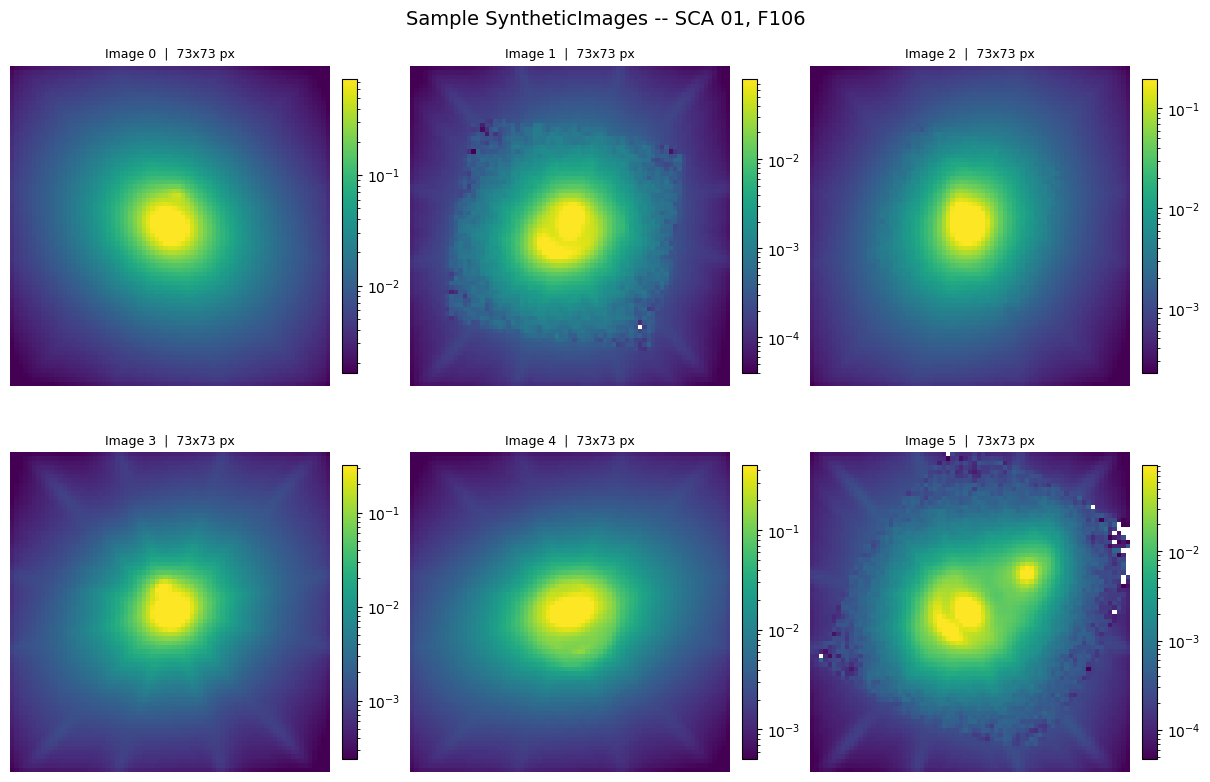

In [4]:
n_show = min(6, n_images)
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
fig.suptitle(f'Sample SyntheticImages -- SCA {DEV_SCA:02d}, {DEV_BAND}', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off')
        continue
    synth = mejiro_util.unpickle(dev_pickles[i])
    data  = synth.data
    vmin  = max(np.nanpercentile(data, 1), 1e-12)
    vmax  = np.nanpercentile(data, 99)
    im = ax.imshow(data, origin='lower', cmap='viridis',
                   norm=LogNorm(vmin=vmin, vmax=max(vmax, vmin * 10)))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'Image {i}  |  {data.shape[0]}x{data.shape[1]} px', fontsize=9)
    ax.axis('off')

plt.show()

## Step 1: Tile SyntheticImages into Detector Array

Each `SyntheticImage` is a 73×73-pixel tile. We lay them out on a 56×56 grid (row-major order) to fill the full 4088×4088 Roman WFI detector array. Pixel values are converted from surface-brightness units to electrons:

    electrons = (pixel / sum_pixels) * (maggies * abflux * exptime)

Negative and NaN pixels are smoothed before tiling.

In [5]:
counts = np.zeros((4088, 4088), dtype=np.float64)

for idx, pickle_path in enumerate(tqdm(dev_pickles, desc='Tiling')):
    synth = mejiro_util.unpickle(pickle_path)

    # smooth negative/NaN pixels
    smooth_data = np.asarray(mejiro_util.smooth_pixels(synth.data), dtype=np.float64)

    # convert surface brightness -> electrons
    synth_sum       = np.sum(smooth_data, dtype=np.float64)
    maggies         = synth.get_maggies()
    total_electrons = maggies * abflux * exptime
    lens_electrons  = (smooth_data / synth_sum) * total_electrons

    # place tile in the detector array (row-major)
    row, col = divmod(idx, GRID_SIDE)
    r0, c0   = row * TILE_SIZE, col * TILE_SIZE
    counts[r0:r0 + TILE_SIZE, c0:c0 + TILE_SIZE] = lens_electrons

print(f'counts: min={counts.min():.3e}, max={counts.max():.3e}')
print(f'NaN: {np.isnan(counts).sum()},  Inf: {np.isinf(counts).sum()}')
print(f'Total electrons in array: {counts.sum():.3e}')

Tiling:  10%|█         | 10/100 [00:00<00:08, 10.68it/s]/data/bwedig/.conda/envs/mejiro-v3/lib/python3.13/site-packages/scipy/ndimage/_filters.py:2420: RuntimeWarning: All-NaN slice encountered
  _nd_image.generic_filter(input, function, footprint, output, mode,
Tiling: 100%|██████████| 100/100 [00:08<00:00, 11.92it/s]

counts: min=0.000e+00, max=4.188e+04
NaN: 0,  Inf: 0
Total electrons in array: 2.482e+07


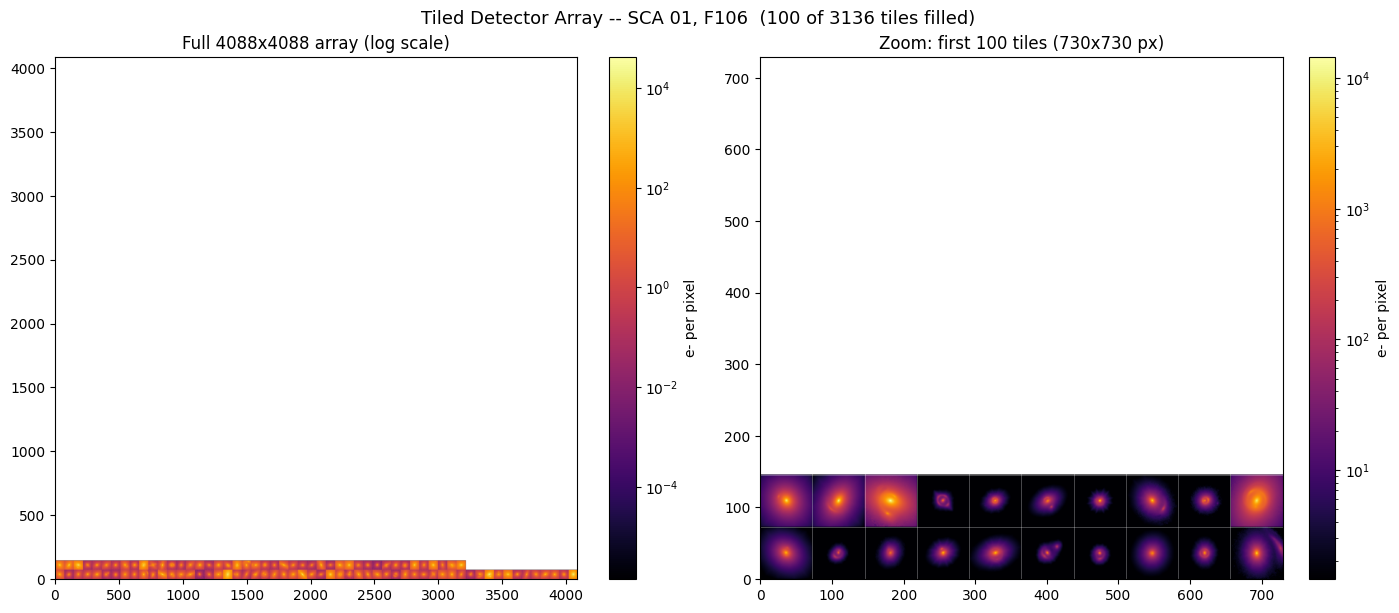

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
fig.suptitle(f'Tiled Detector Array -- SCA {DEV_SCA:02d}, {DEV_BAND}  ({n_images} of {N_TILES} tiles filled)', fontsize=13)

# full array (mask empty tiles)
masked = np.where(counts > 0, counts, np.nan)
im0 = axes[0].imshow(masked, origin='lower', norm=LogNorm(), cmap='inferno')
plt.colorbar(im0, ax=axes[0], label='e- per pixel')
axes[0].set_title('Full 4088x4088 array (log scale)')

# zoom into the populated corner to see individual tiles
n_side  = int(np.ceil(n_images ** 0.5))
zoom_px = n_side * TILE_SIZE
zoom    = counts[:zoom_px, :zoom_px]
vmax_z  = zoom.max()
im1 = axes[1].imshow(zoom, origin='lower', cmap='inferno',
                     norm=LogNorm(vmin=max(vmax_z * 1e-4, 1e-10), vmax=vmax_z))
plt.colorbar(im1, ax=axes[1], label='e- per pixel')
axes[1].set_title(f'Zoom: first {n_images} tiles ({zoom_px}x{zoom_px} px)')

# tile grid overlay
for k in range(n_side + 1):
    axes[1].axhline(k * TILE_SIZE - 0.5, color='w', lw=0.5, alpha=0.4)
    axes[1].axvline(k * TILE_SIZE - 0.5, color='w', lw=0.5, alpha=0.4)

plt.show()

## Step 2: Add Poisson Noise

The `counts` array holds expected electron counts (float). romanisim requires an integer-valued `extra_counts` image, so we draw a Poisson sample to realize shot noise before passing it in.

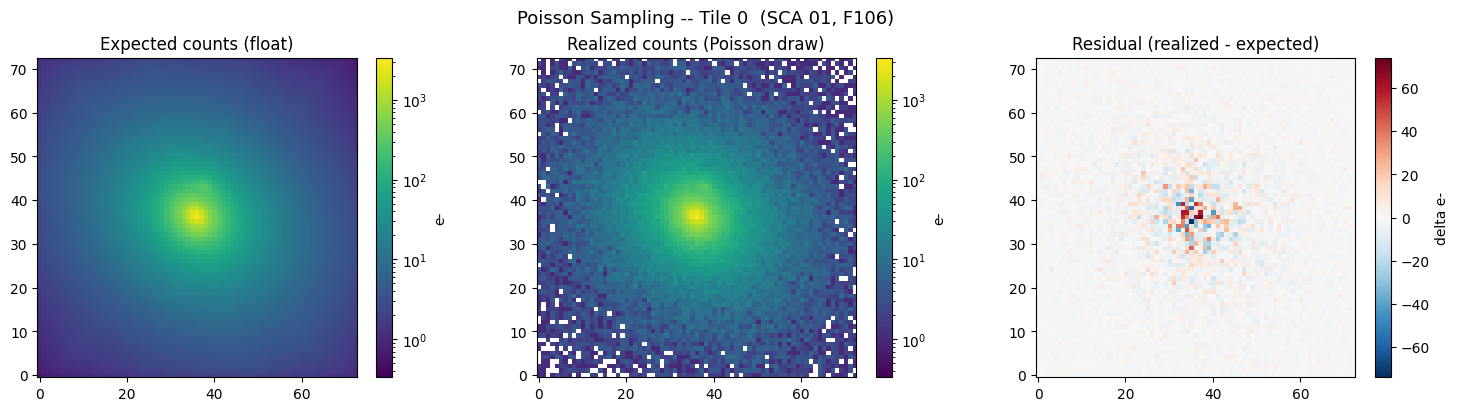

Shot noise (tile 0): std=5.56 e-  (expected sqrt(signal) ~ 5.26 e-)


In [7]:
realized     = rng_np.poisson(counts).astype(np.int32)
extra_counts = galsim.ImageI(realized)  # romanisim expects a GalSim ImageI

# compare a single tile before and after Poisson sampling
row0, col0     = divmod(0, GRID_SIDE)
r0, c0         = row0 * TILE_SIZE, col0 * TILE_SIZE
tile_before    = counts[r0:r0 + TILE_SIZE, c0:c0 + TILE_SIZE]
tile_after     = realized[r0:r0 + TILE_SIZE, c0:c0 + TILE_SIZE].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
fig.suptitle(f'Poisson Sampling -- Tile 0  (SCA {DEV_SCA:02d}, {DEV_BAND})', fontsize=13)

vmax = max(tile_before.max(), tile_after.max())
norm = LogNorm(vmin=max(vmax * 1e-4, 1e-2), vmax=vmax)

im0 = axes[0].imshow(tile_before, origin='lower', norm=norm, cmap='viridis')
plt.colorbar(im0, ax=axes[0], label='e-')
axes[0].set_title('Expected counts (float)')

im1 = axes[1].imshow(tile_after, origin='lower', norm=norm, cmap='viridis')
plt.colorbar(im1, ax=axes[1], label='e-')
axes[1].set_title('Realized counts (Poisson draw)')

diff = tile_after - tile_before
vlim = max(np.abs(diff).max(), 1e-3)
im2  = axes[2].imshow(diff, origin='lower', cmap='RdBu_r', vmin=-vlim, vmax=vlim)
plt.colorbar(im2, ax=axes[2], label='delta e-')
axes[2].set_title('Residual (realized - expected)')

plt.show()
print(f'Shot noise (tile 0): std={diff.std():.2f} e-  (expected sqrt(signal) ~ {np.sqrt(np.clip(tile_before, 0, None).mean()):.2f} e-)')

## Step 3: Set Up romanisim Metadata

Build the metadata dictionary that romanisim uses to configure the detector simulation: SCA identity, filter, MA table (readout pattern), observation time, and WCS pointing.

In [8]:
meta = deepcopy(parameters.default_parameters_dictionary)
meta['instrument']['detector']        = f'WFI{DEV_SCA:02d}'
meta['instrument']['optical_element'] = DEV_BAND
meta['exposure']['ma_table_number']   = ma_table_number
meta['exposure']['read_pattern']      = parameters.read_pattern[ma_table_number]
meta['exposure']['start_time']        = time.Time(date)
wcs.fill_in_parameters(meta, coord, boresight=True)

print('romanisim metadata (key fields):')
print(f"  detector:        {meta['instrument']['detector']}")
print(f"  optical_element: {meta['instrument']['optical_element']}")
print(f"  ma_table_number: {meta['exposure']['ma_table_number']}")
print(f"  read_pattern:    {meta['exposure']['read_pattern']}")
print(f"  start_time:      {meta['exposure']['start_time']}")

romanisim metadata (key fields):
  detector:        WFI01
  optical_element: F106
  ma_table_number: 17
  read_pattern:    [[1, 2], [3, 4], [5, 6], [7, 8, 9, 10, 11, 12], [13, 14, 15, 16, 17, 18, 19, 20], [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48], [49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64], [65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80], [81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96], [97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112], [113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128], [129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160], [161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 19

## Step 4: Create Empty Source Catalog

romanisim renders point sources and extended sources from a catalog. We pass an empty catalog because all flux is already encoded in the `extra_counts` array — we don't want romanisim to render any additional sources.

In [9]:
source_catalog = table.Table({
    'ra':                np.array([], dtype='f8'),
    'dec':               np.array([], dtype='f8'),
    'type':              np.array([], dtype='U3'),
    'n':                 np.array([], dtype='f4'),
    'half_light_radius': np.array([], dtype='f4'),
    'pa':                np.array([], dtype='f4'),
    'ba':                np.array([], dtype='f4'),
    DEV_BAND:            np.array([], dtype='f4'),
})

print(f'Source catalog: {len(source_catalog)} sources')
print('Columns:', source_catalog.colnames)

Source catalog: 0 sources
Columns: ['ra', 'dec', 'type', 'n', 'half_light_radius', 'pa', 'ba', 'F106']


## Step 5: Run romanisim Simulation

Call `image.simulate` with the `extra_counts` array. romanisim applies the full detector-effects chain:

- Ramp sampling (multiaccum readout pattern)
- Interpixel capacitance (IPC)
- Read noise
- Dark current
- Persistence
- Ramp fitting → slope image (L2 data)

The result `im` is a Roman L2 calibrated image object; `extras` holds diagnostic arrays.

In [10]:
print(f'Running romanisim on SCA {DEV_SCA:02d}, {DEV_BAND}...')
im, extras = image.simulate(
    meta, source_catalog,
    usecrds=False,
    psftype='galsim',
    level=2,
    rng=rng,
    crparam=dict(),
    extra_counts=extra_counts,
)
print('Done.')
print(f'Output shape: {im.data.shape}')
print(f'Output dtype: {im.data.dtype}')

2026-04-07 16:45:22,025 WARNING romanisim: --usecrds is not set.  romanisim will not use reference files from CRDS.  The WCS may be incorrect and up-to-date calibration information will not be used.


Running romanisim on SCA 01, F106...


2026-04-07 16:45:23,795 INFO romanisim: Simulating filter F106...
2026-04-07 16:45:24,281 INFO romanisim: Creating PSF using galsim
2026-04-07 16:45:24,829 INFO romanisim: Creating PSF using galsim
2026-04-07 16:45:25,279 INFO romanisim: Creating PSF using galsim
2026-04-07 16:45:25,723 INFO romanisim: Creating PSF using galsim
2026-04-07 16:45:29,557 INFO romanisim: Adding 0 sources to image...
2026-04-07 16:45:29,558 WARNING romanisim: You requested fastpointsources, but the PSF and/or chromaticity are incompatible with this setting.  Disabling fastpointsources.
2026-04-07 16:45:29,630 INFO romanisim: Rendered 0 point sources in 0.045 seconds
2026-04-07 16:45:29,630 INFO romanisim: Rendered 0 total sources in 0.0716 seconds
2026-04-07 16:45:33,619 INFO romanisim: Apportioning electrons to resultants...
2026-04-07 16:51:08,824 INFO romanisim: Adding IPC...
2026-04-07 16:51:14,162 INFO romanisim: Adding read noise...
2026-04-07 16:51:20,316 INFO romanisim: Fitting ramps.
2026-04-07 16:

Done.
Output shape: (4088, 4088)
Output dtype: float32


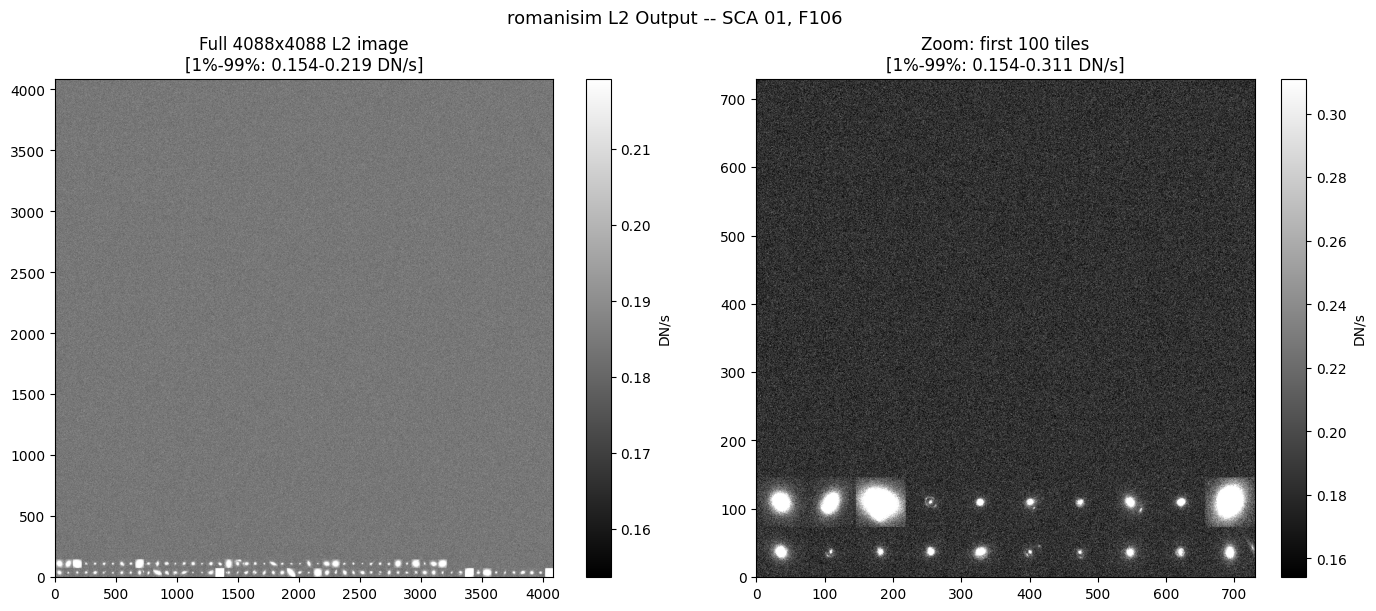

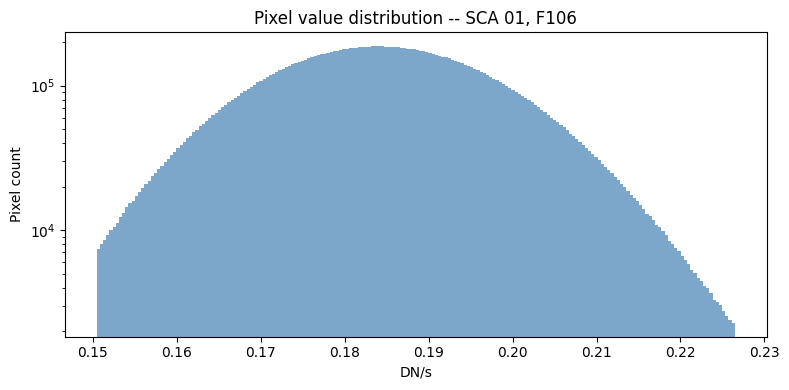

In [11]:
result_data = im.data

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
fig.suptitle(f'romanisim L2 Output -- SCA {DEV_SCA:02d}, {DEV_BAND}', fontsize=13)

# full array
vmin_full = np.nanpercentile(result_data, 1)
vmax_full = np.nanpercentile(result_data, 99)
im0 = axes[0].imshow(result_data, origin='lower', cmap='gray',
                     vmin=vmin_full, vmax=vmax_full)
plt.colorbar(im0, ax=axes[0], label='DN/s')
axes[0].set_title(f'Full 4088x4088 L2 image\n[1%-99%: {vmin_full:.3f}-{vmax_full:.3f} DN/s]')

# zoom into populated region
n_side  = int(np.ceil(n_images ** 0.5))
zoom_px = n_side * TILE_SIZE
zoom    = result_data[:zoom_px, :zoom_px]
vmin_z  = np.nanpercentile(zoom, 1)
vmax_z  = np.nanpercentile(zoom, 99)
im1 = axes[1].imshow(zoom, origin='lower', cmap='gray', vmin=vmin_z, vmax=vmax_z)
plt.colorbar(im1, ax=axes[1], label='DN/s')
axes[1].set_title(f'Zoom: first {n_images} tiles\n[1%-99%: {vmin_z:.3f}-{vmax_z:.3f} DN/s]')

plt.show()

# pixel value histogram
fig, ax = plt.subplots(figsize=(8, 4))
finite_vals = result_data[np.isfinite(result_data)].flatten()
lo, hi = np.percentile(finite_vals, [0.5, 99.5])
ax.hist(finite_vals, bins=200, range=(lo, hi), color='steelblue', alpha=0.7)
ax.set_xlabel('DN/s')
ax.set_ylabel('Pixel count')
ax.set_title(f'Pixel value distribution -- SCA {DEV_SCA:02d}, {DEV_BAND}')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Step 6: Extract Cutouts and Compare

Slice individual 73×73-pixel cutouts from the full romanisim output, matching each tile back to its source `SyntheticImage`. The comparison shows:
- **Row 1**: input synthetic image (flux units)
- **Row 2**: romanisim exposure with detector effects (DN/s)
- **Row 3**: residual after scaling input to match output flux

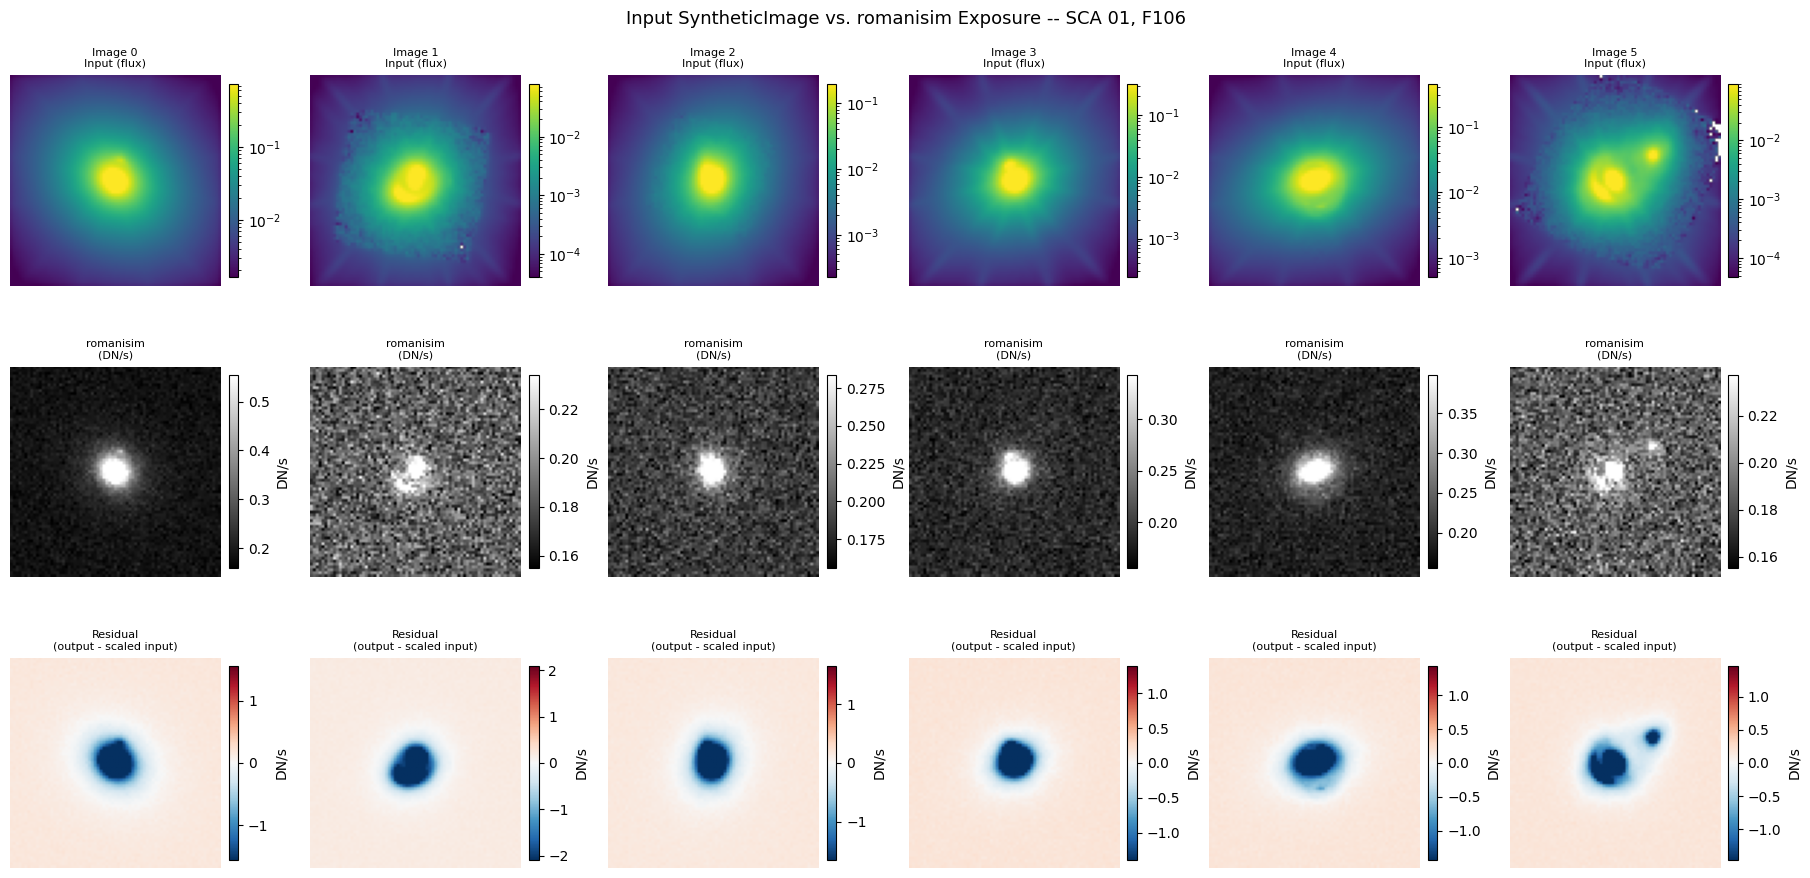

In [12]:
n_show = min(6, n_images)
fig, axes = plt.subplots(3, n_show, figsize=(3 * n_show, 9), constrained_layout=True)
fig.suptitle(f'Input SyntheticImage vs. romanisim Exposure -- SCA {DEV_SCA:02d}, {DEV_BAND}', fontsize=13)

for i in range(n_show):
    # load input
    synth      = mejiro_util.unpickle(dev_pickles[i])
    input_data = synth.data

    # extract output cutout
    row_i, col_i = divmod(i, GRID_SIDE)
    r0_i, c0_i   = row_i * TILE_SIZE, col_i * TILE_SIZE
    cutout       = result_data[r0_i:r0_i + TILE_SIZE, c0_i:c0_i + TILE_SIZE]

    # row 0: input
    vmin_in = max(np.nanpercentile(input_data, 1), 1e-12)
    vmax_in = max(np.nanpercentile(input_data, 99), vmin_in * 10)
    im0 = axes[0, i].imshow(input_data, origin='lower', cmap='viridis',
                             norm=LogNorm(vmin=vmin_in, vmax=vmax_in))
    plt.colorbar(im0, ax=axes[0, i], fraction=0.046, pad=0.04)
    axes[0, i].set_title(f'Image {i}\nInput (flux)', fontsize=8)
    axes[0, i].axis('off')

    # row 1: romanisim output
    vmin_out = np.nanpercentile(cutout, 1)
    vmax_out = np.nanpercentile(cutout, 99)
    im1 = axes[1, i].imshow(cutout, origin='lower', cmap='gray',
                              vmin=vmin_out, vmax=vmax_out)
    plt.colorbar(im1, ax=axes[1, i], fraction=0.046, pad=0.04, label='DN/s')
    axes[1, i].set_title('romanisim\n(DN/s)', fontsize=8)
    axes[1, i].axis('off')

    # row 2: residual (scale input to match output for visual comparison)
    in_sum    = np.nansum(input_data)
    in_scaled = input_data / in_sum * np.nansum(cutout) if in_sum != 0 else input_data
    residual  = cutout - in_scaled
    vlim      = max(np.nanpercentile(np.abs(residual), 98), 1e-6)
    im2 = axes[2, i].imshow(residual, origin='lower', cmap='RdBu_r', vmin=-vlim, vmax=vlim)
    plt.colorbar(im2, ax=axes[2, i], fraction=0.046, pad=0.04, label='DN/s')
    axes[2, i].set_title('Residual\n(output - scaled input)', fontsize=8)
    axes[2, i].axis('off')

plt.show()